{'0': 2047, '1': 2049}


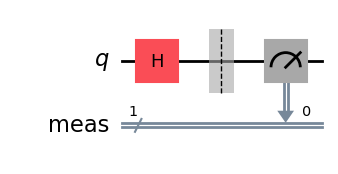

In [1]:
# My first quantum circuit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

# run the simulation
simulator = AerSimulator()
job = simulator.run(qc, shots=4096)
result = job.result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")

In [5]:
# open an instance
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

backends = service.backends(operational=True, simulator=False)

for backend in backends:
    print(backend.name)

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=2
)

print("Selected backend:", backend.name)

ibm_fez
ibm_marrakesh
ibm_kingston
Selected backend: ibm_fez


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

qc.draw("mpl")

simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print(counts)


{'00': 501, '11': 523}


In [2]:
# API Key
# you have to run .json every time you want to run a quantum hardware job on IBM because I am saving API and instance locally

import json
from qiskit_ibm_runtime import QiskitRuntimeService

with open("config.json", "r") as f:
    config = json.load(f)

API_KEY = config["IBM_API_KEY"]
INSTANCE = config["IBM_INSTANCE"]

# run this ONCE in a personal environment
print("Service initializing...")

QiskitRuntimeService.save_account(
    token=API_KEY,
    instance=INSTANCE,
    set_as_default=True,
    overwrite=True
)

# Later, load saved default account like this
service = QiskitRuntimeService()
print("IBM Quantum service loaded successfully")


Service initializing...
IBM Quantum service loaded successfully


In [ ]:
# Running the Qiskit Service
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# create a measured circuit
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

# Load saved IBM Quantum credentials
service = QiskitRuntimeService()
print("[debug] service loaded")

# Select a real quantum backend
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
)

print("[status] selected backend:", backend.name)

# transpile the circuit
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)
isa_circuit = pm.run(qc)

# submit the circuit with SamplerV2
sampler = Sampler(mode=backend)
# job has method to return job_id()
job = sampler.run([isa_circuit], shots=1024)

print("[status] Job ID:", job.job_id())

# retrieve resutls when the job completes
result = job.result()
print(f"[status] result type: {type(result)}")
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print(counts)

# there is a good amount of noise because this is a real quantum circuit, so there are more 1s than 0s for the Hadamard Gate

[debug] service loaded
[status] selected backend: ibm_marrakesh
[status] Job ID: d8s4gmegbcrc73f57brg
[status] result type: <class 'qiskit.primitives.containers.primitive_result.PrimitiveResult'>
{'0': 483, '1': 541}
